In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("AQI_all_stations_2025-10-01.xlsx")
df.head()

,Central Pollution Control Board,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,LIST OF AQI STATIONS Date - Time:01-1...,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,S.No.,State,City,Station Name,Current AQI value
3,1,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",Insufficient data available in last 24 hours.
4,2,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",41


In [5]:
df = pd.read_excel("AQI_all_stations_2025-10-01.xlsx", skiprows=2)
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,S.No.,State,City,Station Name,Current AQI value
1,1,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",Insufficient data available in last 24 hours.
2,2,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",41
3,3,NaN,Anantapur,"Gulzarpet, Anantapur - APPCB",Insufficient data available in last 24 hours.
4,4,NaN,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",89


In [6]:
# Reload file cleanly
df = pd.read_excel(
    "AQI_all_stations_2025-10-01.xlsx",
    skiprows=2
)

df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,S.No.,State,City,Station Name,Current AQI value
1,1,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",Insufficient data available in last 24 hours.
2,2,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",41
3,3,NaN,Anantapur,"Gulzarpet, Anantapur - APPCB",Insufficient data available in last 24 hours.
4,4,NaN,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",89


In [8]:

df.columns = [
    "S_No",
    "State",
    "City",
    "Station",
    "AQI"
]

df.head()

,S_No,State,City,Station,AQI
0,S.No.,State,City,Station Name,Current AQI value
1,1,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",Insufficient data available in last 24 hours.
2,2,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",41
3,3,NaN,Anantapur,"Gulzarpet, Anantapur - APPCB",Insufficient data available in last 24 hours.
4,4,NaN,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",89


In [9]:
df["AQI"] = pd.to_numeric(df["AQI"], errors="coerce")

df = df.dropna(subset=["AQI"])

df.head()

,S_No,State,City,Station,AQI
2,2,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",41.0
4,4,NaN,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",89.0
6,6,NaN,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",48.0
7,7,NaN,Tirumala,"Toll Gate, Tirumala - APPCB",41.0
8,8,NaN,Tirupati,"Vaikuntapuram, Tirupati - APPCB",81.0


In [10]:
df["State"] = df["State"].ffill()

In [11]:
df.isna().sum()

,0
S_No,0
State,0
City,225
Station,0
AQI,0


In [12]:
df["Date"] = "2025-10-01"

In [13]:
df = df[["State", "City", "Station", "AQI", "Date"]]
df.head()

,State,City,Station,AQI,Date
2,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",41.0,2025-10-01
4,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",89.0,2025-10-01
6,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",48.0,2025-10-01
7,Andhra Pradesh,Tirumala,"Toll Gate, Tirumala - APPCB",41.0,2025-10-01
8,Andhra Pradesh,Tirupati,"Vaikuntapuram, Tirupati - APPCB",81.0,2025-10-01


In [14]:
def load_and_clean(file_name, date):
    df = pd.read_excel(file_name)

    # Rename columns properly
    df.columns = ["S_No", "State", "City", "Station", "AQI"]

    # Convert AQI to numeric and drop invalid rows
    df["AQI"] = pd.to_numeric(df["AQI"], errors="coerce")
    df = df.dropna(subset=["AQI"])

    # Fill missing State values
    df["State"] = df["State"].ffill()

    # Add date
    df["Date"] = date

    # Keep required columns
    df = df[["State", "City", "Station", "AQI", "Date"]]

    return df

In [15]:
df_01 = load_and_clean("AQI_all_stations_2025-10-01.xlsx", "2025-10-01")
df_14 = load_and_clean("AQI_all_stations_2025-10-14.xlsx", "2025-10-14")
df_28 = load_and_clean("AQI_all_stations_2025-10-28.xlsx", "2025-10-28")
df_05 = load_and_clean("AQI_all_stations_2025-11-05.xlsx", "2025-11-05")
df_19 = load_and_clean("AQI_all_stations_2025-11-19.xlsx", "2025-11-19")

In [16]:
# Combine all dates into one dataframe
all_data = pd.concat([df_01, df_14, df_28, df_05, df_19], ignore_index=True)

# Quick check
all_data.head()

,State,City,Station,AQI,Date
0,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",41.0,2025-10-01
1,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",89.0,2025-10-01
2,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",48.0,2025-10-01
3,Andhra Pradesh,Tirumala,"Toll Gate, Tirumala - APPCB",41.0,2025-10-01
4,Andhra Pradesh,Tirupati,"Vaikuntapuram, Tirupati - APPCB",81.0,2025-10-01


In [17]:
all_data.columns

Index(['State', 'City', 'Station', 'AQI', 'Date'], dtype='object')

In [18]:
city_avg = all_data.groupby("City")["AQI"].mean().sort_values(ascending=False)
city_avg.head(10)

,AQI
City,
Sonipat,331.333333
Noida,296.200000
Yamuna Nagar,261.500000
Ghaziabad,257.000000
Dharuhera,253.333333
Rohtak,250.200000
Ambala,245.000000
Delhi,227.000000
Greater Noida,226.200000


## Key observations

1) The values of AQI increased signifcantly from october to mid november, indicating that the air quality worsened as winter approached.

2) The increase in pollution levels in mid-november may be attributed to various factors such as accumulation of pollution, wind speed fluctuations and crop-residue burning.

3) The most polluted cities in India are almost all near the Delhi-NCR region, and cities like sonipat, delhi, ghaziabad, Noida record extremely high levels of air pollution.

4) AQI levels show strong regional clustering, suggesting that pollution is influenced by various geographical and seasonal factors.

5) There are many cities that  can be categorized as having very poor to hazardous air quality in India.

6) Most major cities of India consistently have poor to hazardous AQI levels.

## CONCLUSION

This project is designed to analayse the AQI levels of various Indian cities and draw insights about the pollution levels. The data for the analysis was obtained by downloading the publicly available AQI trends (from Oct 2025-mid Nov 2025) from the Central Pollution Control Board (CPCB, India). My analysis revealed that the air quality worsened with the arrival of winter from early October to mid November, and the most polluted cities of India all lay within one region:the NCR-Delhi region. It can also be observed that pollution is influenced by various environmental factors. This project holds the potential to be improved in the future by incorporating  AQI levels across multiple dates and years. The insights gained by this project can help give a better undersatnding of the dynamics of air pollution in India.

## Limitations:

1) The analysis was based on data from a limited lifespan (Oct 2025 - mid Nov 2025)

2) Some monitoring stations reported missing AQI values for some cities.

3) Not all cities have monitoring stations to record AQI values.

## Data source:
The data used for this project was obtained from various open sources such as Central Pollution Control Board (CPCB), Government of India. Google colab was a tool used as the computing environment for the analysis. The data was downloaded from public sources across the above source.

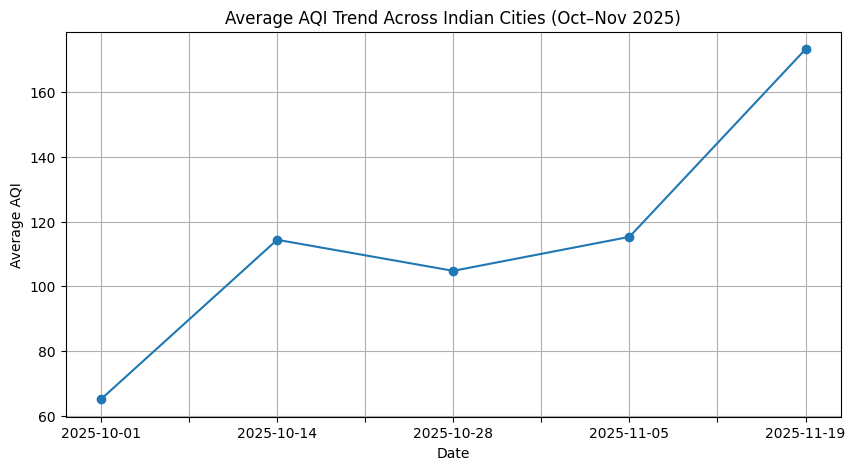

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
all_data.groupby("Date")["AQI"].mean().plot(marker="o")
plt.title("Average AQI Trend Across Indian Cities (Oct–Nov 2025)")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()